# Chapter 20: Industrial Control Systems and OT Security

> "In IT, a security incident costs money. In OT, a security incident can cost lives."

---

## Learning Objectives

After completing this chapter, you will be able to:

1. Distinguish operational technology (OT) from information technology (IT) and explain the convergence challenge.
2. Describe the components of an industrial control system: PLCs, RTUs, HMIs, SCADAs, and DCS.
3. Explain the Purdue Model and the ICS security zones it defines.
4. Describe the unique security challenges of OT environments: availability priority, legacy equipment, long lifecycles.
5. Apply IEC 62443 principles to OT security assessment.
6. Describe known ICS-targeted malware and their operational impact.
7. Explain NIST SP 800-82 guidance for industrial control system security.
8. Design a defence-in-depth architecture appropriate for an OT environment.

## Key Terms

- **OT**: Operational Technology; hardware and software that monitors or controls physical processes.
- **ICS**: Industrial Control System; the collective term for OT control systems.
- **SCADA**: Supervisory Control and Data Acquisition; monitors and controls geographically distributed processes.
- **DCS**: Distributed Control System; controls industrial processes within a single facility.
- **PLC**: Programmable Logic Controller; a ruggedised computer controlling physical actuators.
- **RTU**: Remote Terminal Unit; a field device collecting data from sensors and sending to SCADA.
- **HMI**: Human-Machine Interface; the operator console for viewing and controlling the process.
- **Engineering Workstation (EWS)**: laptop or PC used to programme PLCs and update firmware.
- **Purdue Model**: hierarchical reference model for ICS network architecture.
- **Air gap**: physical separation between networks with no network connection.
- **IEC 62443**: international standard for industrial automation and control system security.
- **Stuxnet**: the first publicly documented cyberweapon targeting physical infrastructure.

---

## IT Versus OT: A Fundamental Difference in Priorities

In IT, the CIA triad prioritises Confidentiality first. In OT, the priority is inverted:
Availability and Integrity come first; Confidentiality is often secondary. A power plant
control system that goes offline to apply a patch causes a real-world outage. An unpatched
PLC that continues controlling a turbine is acceptable from the operations perspective; an
unavailable PLC is not. This fundamental difference means that IT security practices cannot
be directly transplanted to OT environments without adaptation.

### Safety as the Overriding Priority

OT security must consider physical safety consequences. A chemical plant process controller
that is manipulated by a threat actor could set temperatures or pressures outside safe
operating ranges, causing equipment damage or endangering workers. Safety instrumented
systems (SIS) provide independent protection layers designed to bring the process to a safe
state if dangerous conditions are detected.

---

## ICS Components

### Programmable Logic Controllers

PLCs are the workhorses of industrial automation. They execute deterministic control logic
(scan-read inputs, execute ladder logic, write outputs) at cycle times measured in milliseconds.
PLCs are designed for 24/7 operation, harsh environments, and 20-30 year lifecycles. They were
designed for availability and functionality, not security: many PLCs have no authentication,
communicate over unauthenticated protocols (Modbus, DNP3, Profibus), and cannot be easily
patched without a maintenance window.

### SCADA Systems

SCADA systems collect data from widely distributed RTUs (substations, pumping stations, remote
sensors) over wide-area networks and provide centralised monitoring and control. The wide-area
connectivity that makes SCADA useful also creates an attack surface: SCADA communications may
traverse public networks, telecommunications infrastructure, or satellite links, each of which
represents a potential entry point.

### Human-Machine Interfaces

The HMI is the operator's view into the process. Operators issue commands and receive alarms
through the HMI. A compromised HMI can deceive operators by showing false process values while
the underlying process deviates from safe parameters -- exactly the technique used by Stuxnet,
which displayed normal centrifuge speed readings while commanding the centrifuges to spin at
damaging speeds.

---

## The Purdue Model and Network Segmentation

The Purdue Model (also called the Purdue Enterprise Reference Architecture, PERA) organises
ICS networks into hierarchical levels:

| Level | Name | Components |
|---|---|---|
| 0 | Field Level | Physical sensors, actuators, motors, valves |
| 1 | Control Level | PLCs, RTUs, safety systems |
| 2 | Supervisory Level | SCADA servers, DCS, HMIs |
| 3 | Manufacturing Operations | Historian servers, MES, engineering workstations |
| 3.5 | Industrial DMZ | Data diodes, jump servers, protocol converters |
| 4 | Business Logistics | Enterprise IT: ERP, email, internet |

### The Industrial DMZ

The industrial DMZ (Level 3.5) is a critical security control: it mediates all communication
between the OT network (Levels 0-3) and the IT network (Level 4). Traffic should flow through
protocol-aware firewalls or data diodes (hardware devices allowing data flow in one direction
only). No direct connectivity should exist between the enterprise network and the control
network.

### Air Gaps and Their Limitations

An air gap (complete physical separation with no network connection) is the most secure
boundary between IT and OT. However, true air gaps are increasingly rare because business
requirements demand data from the plant floor (historian data for analysis, remote
diagnostics). Even an air-gapped network is vulnerable to removable media (Stuxnet spread
via USB), engineering workstations that connect to both networks, and vendor remote access.

---

## OT-Specific Security Challenges

### Legacy Equipment and Long Lifecycles

OT equipment has lifecycles of 20-30 years. A PLC installed in 2000 may be running firmware
from that era, with no vendor support, no patches available, and no ability to install an agent.
The security controls applicable to a modern Windows endpoint (patching, AV, EDR) cannot be
applied to a legacy PLC. Compensating controls (network segmentation, monitoring at the protocol
level, application whitelisting on the engineering workstation) are required.

### Availability Requirements

Many OT processes cannot be interrupted: a nuclear power plant, a chemical reactor, or a water
treatment system cannot be rebooted to apply a patch. Maintenance windows are infrequent and
tightly controlled. Vulnerability management in OT requires coordination with operations,
risk acceptance for vulnerabilities that cannot be patched, and compensating controls.

### Protocol Insecurity

Industrial protocols were designed for reliability and determinism, not security. Modbus has
no authentication: any device that can send a valid Modbus command can control a PLC. DNP3
added authentication in DNP3 Secure Authentication v5, but deployment is limited. PROFINET
and EtherNet/IP are Ethernet-based and susceptible to standard network attacks. Protocol-aware
monitoring tools (Claroty, Dragos, Nozomi) can detect anomalous commands even without agent
deployment.

---

## ICS Malware Case Studies

### Stuxnet (2010)

Stuxnet is widely considered the first publicly documented cyberweapon designed to cause physical
damage. It targeted Siemens S7-315 PLCs controlling Iranian uranium enrichment centrifuges,
commanding them to spin at damaging speeds while reporting normal operation to the SCADA system.
Stuxnet demonstrated that sophisticated OT attacks can achieve physical effects equivalent to
sabotage and that even air-gapped networks are not fully protected against insider or supply-chain
delivery of malicious code.

### Industroyer/CRASHOVERRIDE (2016)

Industroyer (also called CRASHOVERRIDE) targeted Ukraine's power grid, causing a blackout
affecting approximately 230,000 customers. It implemented native ICS protocol handlers for
IEC 60870-5-101, IEC 60870-5-104, IEC 61850, and OPC DA, allowing it to interact directly
with power grid components without requiring PLC-specific code.

### TRITON/TRISIS (2017)

TRITON targeted Schneider Electric Safety Instrumented System (SIS) controllers in a Middle
Eastern petrochemical facility. It attempted to disable safety systems, which would have allowed
dangerous process conditions to develop without triggering protective shutdowns. This attack
was the first publicly documented attempt to deliberately disable safety systems, with potential
consequences including explosion or toxic release.

---

## IEC 62443 and NIST SP 800-82

### IEC 62443

IEC 62443 {cite}`iec_62443` is the international standard for industrial automation and control
system security. It defines: Security Levels (SL 0-4, from no requirements to protection against
state-level adversaries), zones and conduits (grouping components by security requirements and
managing communication between zones), and requirements for operators, integrators, and component
manufacturers.

### NIST SP 800-82

NIST SP 800-82 {cite}`nist_sp800_82` provides guidance specific to industrial control system
security, adapted from NIST 800-53 for the OT context. It acknowledges the unique OT constraints
(availability priority, legacy equipment, infrequent patching) and provides tailored control
baselines for ICS environments.

---

## OT Defence-in-Depth

A layered OT security architecture applies the defence-in-depth principle across the Purdue levels:

- **Level 0-1**: physical security (locked cabinets, tamper-evident seals), network-level
  access control (only authorised engineering workstations can send configuration commands to PLCs).
- **Level 2-3**: protocol-aware firewalls (Modbus, DNP3, PROFINET inspection), OT-specific
  intrusion detection (anomalous commands, unusual data volumes), HMI hardening (application
  whitelisting, no internet access).
- **Level 3.5 (Industrial DMZ)**: data diodes for historian replication (one-way), jump servers
  with MFA for engineer access, protocol conversion (translate OT protocols to IT-safe formats).
- **Level 4**: standard IT controls on all enterprise systems; no direct connectivity to OT levels.

---

## Why This Matters

The convergence of IT and OT -- driven by business demand for data and remote access --
has connected previously isolated control networks to the internet. This connectivity
brings significant business benefits and significant security risk. Attacks on industrial
infrastructure have caused real physical damage, power outages, and unsafe conditions.
Unlike IT breaches, OT attacks can kill people. The security practitioner who understands
both environments is positioned to design and operate the compensating controls that allow
connectivity while maintaining safety.

---

## News in Focus

Several publicly documented attacks on water treatment facilities have involved threat actors
gaining access to SCADA systems and attempting to adjust chemical dosing parameters. In a
documented US incident, a threat actor gained access via a remote access tool and attempted
to increase sodium hydroxide concentration to dangerous levels. An operator detected the
anomalous cursor movement on the HMI and reversed the change before any harm occurred.
The detection was human, not automated -- underscoring that OT monitoring and operator
training are both essential layers of defence.

---


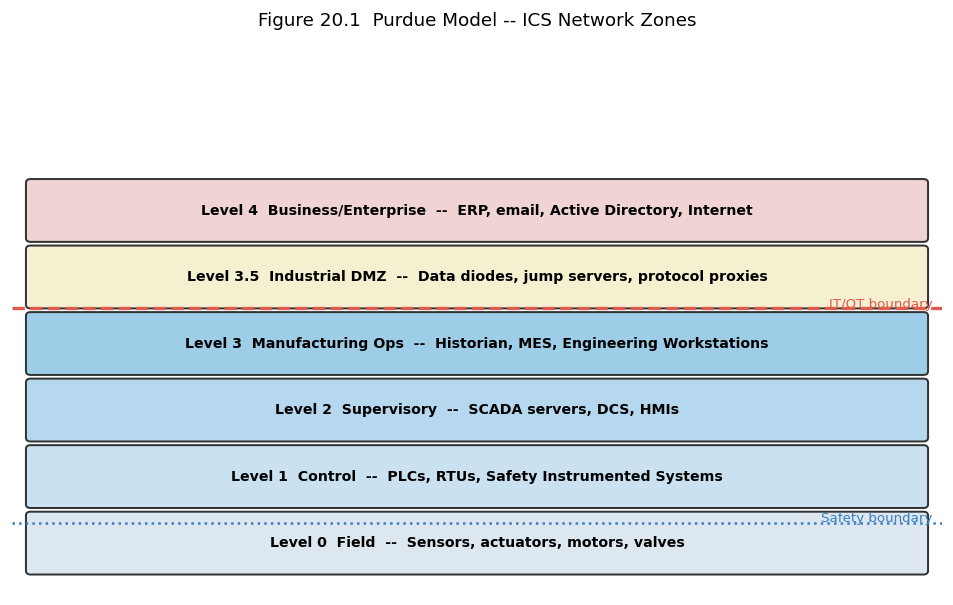

Figure 20.1 rendered.

=== OT Network Connection Policy Audit ===

  L.Src->L.Dst   Protocol   Status
  ---------------------------------------------------------------------------
  L4->L3         RDP        COMPLIANT
  L3->L4         Modbus     COMPLIANT
  L4->L1         ping       CRITICAL: Direct IT-to-control-level connection bypasses industrial DMZ
  L3->L4         OPC-DA     COMPLIANT
  L2->L4         HTTP       CRITICAL: Direct IT-to-control-level connection bypasses industrial DMZ; WARNING: OT->IT flow should use data diode unless historian replication


In [1]:
# Chapter 20 -- Purdue model zone validator and OT risk scorer

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from io import BytesIO
from IPython.display import display, Image
from dataclasses import dataclass
from typing import List

# ── Purdue Model visualisation ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(0, 7.5)

levels = [
    ("Level 0  Field",               "Sensors, actuators, motors, valves",          "#dde7f0", 0.3),
    ("Level 1  Control",             "PLCs, RTUs, Safety Instrumented Systems",      "#c9e1f0", 1.2),
    ("Level 2  Supervisory",         "SCADA servers, DCS, HMIs",                    "#b5d8ef", 2.1),
    ("Level 3  Manufacturing Ops",   "Historian, MES, Engineering Workstations",     "#9ecde8", 3.0),
    ("Level 3.5  Industrial DMZ",    "Data diodes, jump servers, protocol proxies",  "#f5f0cf", 3.9),
    ("Level 4  Business/Enterprise", "ERP, email, Active Directory, Internet",       "#f0d4d4", 4.8),
]

for label, components, color, y in levels:
    ax.add_patch(mpatches.FancyBboxPatch((0.2, y), 9.6, 0.75,
                 boxstyle="round,pad=0.05", facecolor=color, edgecolor="#333", lw=1.2))
    ax.text(5.0, y+0.38, f"{label}  --  {components}",
            ha="center", va="center", fontsize=8.5, fontweight="bold")

# Boundary lines
ax.axhline(3.85, color="#e05a4e", lw=2, ls="--")
ax.text(9.9, 3.87, "IT/OT boundary", color="#e05a4e", fontsize=8, ha="right")
ax.axhline(0.95, color="#3a7ebf", lw=1.5, ls=":")
ax.text(9.9, 0.97, "Safety boundary", color="#3a7ebf", fontsize=8, ha="right")

ax.set_title("Figure 20.1  Purdue Model -- ICS Network Zones", fontsize=11, pad=8)

_buf = BytesIO()
plt.savefig(_buf, format="png", dpi=120, bbox_inches="tight")
plt.close(); _buf.seek(0)
display(Image(data=_buf.read()))
print("Figure 20.1 rendered.")

# ── OT zone policy checker ─────────────────────────────────────────────────────
@dataclass
class Connection:
    src_zone: int
    dst_zone: int
    protocol: str
    direction: str
    note: str

def ot_policy_check(conn: Connection) -> str:
    violations = []
    # No direct connection between Level 4 and Level 0-2
    if (conn.src_zone >= 4 and conn.dst_zone <= 2) or \
       (conn.dst_zone >= 4 and conn.src_zone <= 2):
        violations.append("CRITICAL: Direct IT-to-control-level connection bypasses industrial DMZ")
    # Only one-way flows from OT to IT are acceptable for historian data
    if conn.src_zone <= 3 and conn.dst_zone == 4 and "historian" not in conn.note.lower():
        violations.append("WARNING: OT->IT flow should use data diode unless historian replication")
    # No internet-routable protocols in Level 0-3
    if conn.dst_zone <= 3 and conn.protocol in ["HTTP", "SMTP", "FTP"]:
        violations.append("WARNING: IT protocol in OT zone -- verify necessity and implement controls")
    # Level 3.5 must mediate all cross-boundary traffic
    if conn.src_zone == 4 and conn.dst_zone == 3 and "dmz" not in conn.note.lower():
        violations.append("VIOLATION: Level 4 connecting to Level 3 without traversing DMZ (3.5)")
    return "; ".join(violations) if violations else "COMPLIANT"

connections = [
    Connection(4, 3, "RDP",     "->", "Engineer remote access -- should go via jump server in DMZ"),
    Connection(3, 4, "Modbus",  "->", "Historian replication of process data"),
    Connection(4, 1, "ping",    "->", "IT admin checking PLC availability directly"),
    Connection(3, 4, "OPC-DA",  "->", "Historian data via data diode in DMZ"),
    Connection(2, 4, "HTTP",    "->", "HMI software update from internet"),
]

print("\n=== OT Network Connection Policy Audit ===\n")
print(f"  {'L.Src->L.Dst':<14} {'Protocol':<10} {'Status'}")
print("  " + "-"*75)
for c in connections:
    status = ot_policy_check(c)
    print(f"  L{c.src_zone}->L{c.dst_zone}         {c.protocol:<10} {status}")


## Review Questions (MCQ)

**Q1.** In OT environments, the priority ordering of the CIA triad differs from IT in that:
A. Confidentiality takes priority over Availability  B. Availability and Integrity are prioritised over Confidentiality  C. Integrity is irrelevant in OT  D. All three are equally weighted

**Q2.** A PLC (Programmable Logic Controller) is best described as:
A. A network firewall for industrial networks  B. A ruggedised computer executing deterministic control logic for physical actuators  C. A SCADA server  D. A human-machine interface

**Q3.** The Purdue Model Level 3.5 (Industrial DMZ) is designed to:
A. House all PLCs  B. Mediate all traffic between the OT network and the enterprise IT network  C. Replace the air gap entirely  D. Provide internet access to operators

**Q4.** Stuxnet was significant because it:
A. Was the first computer virus  B. Targeted Windows desktop PCs  C. Was the first publicly documented cyberweapon causing physical damage to industrial equipment  D. Attacked internet infrastructure

**Q5.** TRITON/TRISIS was most alarming because it:
A. Encrypted historian data  B. Targeted Safety Instrumented Systems, the last protection layer before physical harm  C. Caused a power blackout  D. Spread via USB drives

**Q6.** Modbus lacks which fundamental security property?
A. Reliability  B. Determinism  C. Authentication  D. Speed

**Q7.** A data diode is used in OT security to:
A. Convert OT protocols to IT protocols  B. Allow network traffic to flow in one direction only  C. Authenticate PLC commands  D. Replace the firewall

**Q8.** IEC 62443 Security Level 4 is designed to protect against:
A. Accidental misconfiguration  B. Script kiddies  C. Nation-state adversaries with sophisticated capabilities  D. Physical theft

**Q9.** The engineering workstation (EWS) is a high-value OT target because:
A. It runs Windows XP  B. It is used to programme PLCs and may have connectivity to both IT and OT networks  C. It stores historian data  D. It provides internet access to operators

**Q10.** The most effective compensating control when an OT device cannot be patched is:
A. Ignoring the vulnerability until a maintenance window is available  B. Network segmentation and protocol-aware monitoring to limit exposure and detect exploitation  C. Installing endpoint antivirus  D. Changing the default password

*Answers: Q1 B, Q2 B, Q3 B, Q4 C, Q5 B, Q6 C, Q7 B, Q8 C, Q9 B, Q10 B.*

## Lab Assignment

**Part A -- Purdue zone mapping**: For a fictional water treatment plant (control room PCs, 12 PLCs, 3 RTUs at remote pump stations, a SCADA server, a historian, and an enterprise ERP system), map every component to its Purdue level. Identify all data flows between levels and flag any that violate the industrial DMZ principle.

**Part B -- OT risk assessment**: Using the OT connection checker above, add five connections of your own design. For each connection you flag as a violation, propose a compensating control or architecture change that would make it compliant.

**Part C -- Stuxnet case study**: Research the publicly documented technical details of Stuxnet. Write a two-page technical summary covering: initial infection vector, propagation mechanism, PLC targeting logic, the operator-deception technique used to hide the attack, and the three controls that, if in place, might have detected or prevented the attack.

**Part D -- IEC 62443 zone design**: For a chemical plant with three process areas (reaction, separation, storage) and a central control room, design an IEC 62443-compliant zone and conduit model. Specify the security level for each zone, the conduit controls between zones, and justify your security-level assignments.

## References

```{bibliography}
:filter: docname in docnames
```


```{index} OT, ICS, SCADA, DCS, PLC, RTU, HMI, Engineering Workstation, Purdue Model, Air gap, IEC 62443, Stuxnet
```
